# Install

In [ ]:
# Kiem tra GPU (bat buoc: Runtime > Change runtime type > Hardware accelerator > GPU)
import subprocess
try:
    print(subprocess.check_output(["nvidia-smi"]).decode())
except Exception:
    print("KHONG tim thay GPU! Vao menu Runtime > Change runtime type > chon GPU (T4) roi chay lai.")


Sat Aug 29 00:54:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# (TUY CHON) Mount Google Drive de luu ket qua/model lau dai, tranh mat khi Colab ngat phien
# Bo comment 2 dong duoi neu muon dung:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# Colab khong co san unrar nhu Kaggle -> can cai dat truoc khi giai nen file .rar
!apt-get -qq update && apt-get -qq install -y unrar


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
!pip install -q gdown
import gdown, os

WORK_DIR = "/content"
DATASETS_DIR = f"{WORK_DIR}/datasets"
os.makedirs(DATASETS_DIR, exist_ok=True)

FOLDER_ID = "1HrZ2PqalGUQhEsnZh24-DDBiXgweO7rn"
FOLDER_URL = f"https://drive.google.com/drive/folders/{FOLDER_ID}"

gdown.download_folder(url=FOLDER_URL, output=DATASETS_DIR, quiet=True, use_cookies=False)

['/content/datasets/board_segmentation.rar',
 '/content/datasets/figure_direction_classification.rar']

In [ ]:
def print_tree(root, max_depth=3, _depth=0, _prefix=""):
    if _depth > max_depth:
        return
    try:
        entries = sorted(os.listdir(root))
    except NotADirectoryError:
        return
    for entry in entries:
        path = os.path.join(root, entry)
        print(_prefix + entry + ("/" if os.path.isdir(path) else ""))
        if os.path.isdir(path):
            print_tree(path, max_depth, _depth + 1, _prefix + "    ")

In [ ]:
import os
import glob

# Đổi định dạng tìm kiếm sang .rar
rar_files = glob.glob(f"{DATASETS_DIR}/**/*.rar", recursive=True)

for rpath in rar_files:
    extract_to = rpath[:-4]  # Bỏ ".rar" (4 ký tự cuối)
    print(f"Đang giải nén: {rpath} -> {extract_to} ...")

    # Tạo thư mục đích nếu nó chưa tồn tại
    os.makedirs(extract_to, exist_ok=True)

    # Gọi lệnh hệ thống unrar của Linux
    # 'x' : giải nén giữ nguyên cấu trúc thư mục
    # '-o+' : tự động ghi đè nếu file đã tồn tại
    # '> /dev/null 2>&1' : Chuyển toàn bộ text log hiển thị vào vùng trống để ẩn đi
    os.system(f'unrar x -o+ "{rpath}" "{extract_to}/" > /dev/null 2>&1')

if rar_files:
    print("\nĐã giải nén xong toàn bộ, kiểm tra lại cây thư mục:")
    print_tree(DATASETS_DIR)
else:
    print("Không tìm thấy file .rar nào.")

Đang giải nén: /content/datasets/board_segmentation.rar -> /content/datasets/board_segmentation ...
Đang giải nén: /content/datasets/figure_direction_classification.rar -> /content/datasets/figure_direction_classification ...

Đã giải nén xong toàn bộ, kiểm tra lại cây thư mục:
board_segmentation/
    board_segmentation/
        data.yaml
        train/
            images/
            labels/
        val/
            images/
            labels/
            labels.cache
board_segmentation.rar
figure_direction_classification/
    figure_direction_classification/
        BISHOP/
            DOWN/
            UP/
        BISHOP_PROM/
            DOWN/
            UP/
        EMPTY/
            NONE/
        GOLD/
            DOWN/
            UP/
        KING/
            DOWN/
            UP/
        KNIGHT/
            DOWN/
            NONE/
            UP/
        KNIGHT_PROM/
            DOWN/
            UP/
        LANCE/
            DOWN/
            UP/
        LANCE_PROM/
       

In [ ]:
BOARD_DATASET_DIR = f"{DATASETS_DIR}/board_segmentation"
FIGURE_DATASET_DIR = f"{DATASETS_DIR}/figure_direction_classification"

assert os.path.isdir(BOARD_DATASET_DIR), f"Khong tim thay: {BOARD_DATASET_DIR} - kiem tra lai ten thu muc o cell print_tree ben tren"
assert os.path.isdir(FIGURE_DATASET_DIR), f"Khong tim thay: {FIGURE_DATASET_DIR} - kiem tra lai ten thu muc o cell print_tree ben tren"
print("Duong dan dataset hop le.")

Duong dan dataset hop le.


In [ ]:
!pip install -q ultralytics
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.7 MB/s eta 0:00:00
CUDA available: True
Device: Tesla T4


# Skip training

In [ ]:
# import os, shutil, zipfile, glob
# import torch
# from torch import nn
# from torchvision import transforms
# from PIL import Image

# try:
#     from google.colab import files as colab_files
#     IN_COLAB = True
# except ImportError:
#     IN_COLAB = False

# WORK_DIR = "/content"
# os.makedirs(f"{WORK_DIR}/runs", exist_ok=True)
# os.makedirs(f"{WORK_DIR}/uploaded_models", exist_ok=True)

# # ============================================================
# # 1. UPLOAD FILE
# # ============================================================
# print("Chọn file để upload: best.pt, model_b_figure_direction.pt, (tuỳ chọn) board_corner_seg_results.zip")
# print("(Có thể chọn nhiều file cùng lúc)\n")

# if IN_COLAB:
#     uploaded = colab_files.upload()  # dict: filename -> bytes
# else:
#     raise RuntimeError("Cell này dành cho Google Colab. Hãy copy file thủ công vào /content/uploaded_models/")

# # Lưu file upload vào thư mục riêng
# for fname, data in uploaded.items():
#     dest = f"{WORK_DIR}/uploaded_models/{fname}"
#     with open(dest, "wb") as f:
#         f.write(data)
#     print(f"Đã lưu: {dest}")

# # ============================================================
# # 2. XỬ LÝ MODEL A (best.pt)
# # ============================================================
# model_a_path = None

# # Ưu tiên file best.pt upload trực tiếp
# candidates_a = [
#     f"{WORK_DIR}/uploaded_models/best.pt",
#     f"{WORK_DIR}/best.pt",
# ]
# for p in candidates_a:
#     if os.path.exists(p):
#         # Đặt vào cấu trúc runs/ mà pipeline test đang tìm
#         run_dir = f"{WORK_DIR}/runs/board_corner_seg_uploaded"
#         os.makedirs(f"{run_dir}/weights", exist_ok=True)
#         dest_pt = f"{run_dir}/weights/best.pt"
#         shutil.copy(p, dest_pt)
#         model_a_path = dest_pt
#         print(f"Model A (best.pt) → {model_a_path}")
#         break

# # Nếu upload zip kết quả train
# zip_path = f"{WORK_DIR}/uploaded_models/board_corner_seg_results.zip"
# if model_a_path is None and os.path.exists(zip_path):
#     extract_dir = f"{WORK_DIR}/runs/board_corner_seg_uploaded"
#     os.makedirs(extract_dir, exist_ok=True)
#     with zipfile.ZipFile(zip_path, "r") as z:
#         z.extractall(extract_dir)
#     found = glob.glob(f"{extract_dir}/**/best.pt", recursive=True)
#     if found:
#         model_a_path = found[0]
#         print(f"Model A (từ zip) → {model_a_path}")

# if model_a_path is None:
#     # Thử tìm trong runs cũ
#     run_dirs = sorted(glob.glob(f"{WORK_DIR}/runs/board_corner_seg*"), key=os.path.getmtime, reverse=True)
#     for d in run_dirs:
#         candidate = f"{d}/weights/best.pt"
#         if os.path.exists(candidate):
#             model_a_path = candidate
#             print(f"Model A (đã có sẵn) → {model_a_path}")
#             break

# if model_a_path is None:
#     print("Chưa có best.pt – bạn cần upload hoặc train Model A.")
# else:
#     print(f"model_a_path = {model_a_path}")

# # ============================================================
# # 3. CHUẨN BỊ YOLOv5 (cần cho predict, không cần train)
# # ============================================================
# if not os.path.exists(f"{WORK_DIR}/yolov5"):
#     print("Đang clone YOLOv5...")
#     os.system(f"git clone -q https://github.com/ultralytics/yolov5.git {WORK_DIR}/yolov5")
#     os.system(f"pip install -qr {WORK_DIR}/yolov5/requirements.txt")
#     print("YOLOv5 sẵn sàng.")
# else:
#     print("YOLOv5 đã có sẵn.")

# # ============================================================
# # 4. LOAD MODEL B
# # ============================================================
# # PadToSquare (cần cho transform)
# class PadToSquare:
#     def __init__(self, fill=0):
#         self.fill = fill
#     def __call__(self, img: Image.Image) -> Image.Image:
#         w, h = img.size
#         if w == h:
#             return img
#         size = max(w, h)
#         new_img = Image.new(img.mode, (size, size), color=self.fill)
#         new_img.paste(img, ((size - w) // 2, (size - h) // 2))
#         return new_img

# transform = transforms.Compose([
#     PadToSquare(fill=0),
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
# ])

# # Lấy FIGURE_CLASSES từ dataset (nếu đã giải nén) hoặc hardcode
# FIGURE_DATASET_DIR = f"{WORK_DIR}/datasets/figure_direction_classification"
# if os.path.isdir(os.path.join(FIGURE_DATASET_DIR, "figure_direction_classification")):
#     FIGURE_DATASET_DIR = os.path.join(FIGURE_DATASET_DIR, "figure_direction_classification")

# if os.path.isdir(FIGURE_DATASET_DIR):
#     FIGURE_CLASSES = sorted([
#         d for d in os.listdir(FIGURE_DATASET_DIR)
#         if os.path.isdir(os.path.join(FIGURE_DATASET_DIR, d))
#     ])
# else:
#     # Fallback nếu chưa giải nén dataset
#     FIGURE_CLASSES = [
#         "BISHOP", "BISHOP_PROM", "EMPTY", "GOLD", "KING",
#         "KNIGHT", "KNIGHT_PROM", "LANCE", "LANCE_PROM",
#         "PAWN", "PAWN_PROM", "ROOK", "ROOK_PROM", "SILVER", "SILVER_PROM",
#     ]
#     print("Dùng FIGURE_CLASSES hardcode (chưa tìm thấy dataset).")

# DIRECTION_CLASSES = ["UP", "DOWN"]
# print(f"FIGURE_CLASSES ({len(FIGURE_CLASSES)}): {FIGURE_CLASSES}")

# class MixedClassifier(nn.Module):
#     def __init__(self, num_figures, num_directions=2):
#         super().__init__()
#         self.backbone = nn.Sequential(
#             nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
#             nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
#             nn.AdaptiveAvgPool2d(1),
#         )
#         self.fc_figure = nn.Linear(128, num_figures)
#         self.fc_direction = nn.Linear(128, num_directions)

#     def forward(self, x):
#         feat = self.backbone(x).flatten(1)
#         return self.fc_figure(feat), self.fc_direction(feat)

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model_b = MixedClassifier(num_figures=len(FIGURE_CLASSES)).to(device)

# model_b_candidates = [
#     f"{WORK_DIR}/uploaded_models/model_b_figure_direction.pt",
#     f"{WORK_DIR}/model_b_figure_direction.pt",
# ]
# model_b_loaded = False
# for p in model_b_candidates:
#     if os.path.exists(p):
#         state = torch.load(p, map_location=device)
#         model_b.load_state_dict(state)
#         model_b.eval()
#         # Copy ra WORK_DIR để các cell khác tìm thấy
#         shutil.copy(p, f"{WORK_DIR}/model_b_figure_direction.pt")
#         print(f"Model B loaded từ {p}")
#         model_b_loaded = True
#         break

# if not model_b_loaded:
#     print("Chưa có model_b_figure_direction.pt – bạn cần upload hoặc train Model B.")

# print("\n" + "="*50)
# print("Tóm tắt:")
# print(f"  model_a_path : {model_a_path}")
# print(f"  model_b      : {'OK' if model_b_loaded else 'THIẾU'}")
# print(f"  device       : {device}")
# print("="*50)
# print("→ Có thể bỏ qua section Model A & Model B (train), chạy thẳng section Test.")

# Train Model A (nhận biết bàn cờ nằm đâu)

In [ ]:
import yaml
import os
import glob

# 1. THIẾT LẬP ĐƯỜNG DẪN
WORK_DIR = "/content"
dataset_dir = f"{WORK_DIR}/datasets/board_segmentation"

# Tự động tìm file .yaml trong dataset
yaml_files = glob.glob(f"{dataset_dir}/**/*.yaml", recursive=True)
if not yaml_files:
    raise FileNotFoundError(f"Không tìm thấy file .yaml nào trong {dataset_dir}")

yaml_path = yaml_files[0]

# 2. ĐỌC VÀ SỬA LẠI FILE YAML (Bắt buộc cho YOLOv5)
with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

# Ép đường dẫn tuyệt đối cho train và val
data_cfg['train'] = f"{dataset_dir}/train"
data_cfg['val'] = f"{dataset_dir}/val"

# Xóa key 'path' đi để YOLOv5 không bị nhầm lẫn
if 'path' in data_cfg:
    del data_cfg['path']

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f"Đã sửa xong file cấu hình tại: {yaml_path}")

# Lưu biến môi trường để truyền vào Bash
os.environ['YAML_PATH'] = yaml_path
os.environ['WORK_DIR'] = WORK_DIR

Đã sửa xong file cấu hình tại: /content/datasets/board_segmentation/board_segmentation/data.yaml


In [ ]:
import yaml
import os
import glob
from IPython.display import display
try:
    from google.colab import files as colab_files
    IN_COLAB = True
except ImportError:
    from IPython.display import FileLink
    IN_COLAB = False

def offer_download(path):
    """Tai file ve may: dung google.colab.files tren Colab, FileLink khi chay noi khac."""
    if IN_COLAB:
        colab_files.download(path)
    else:
        display(FileLink(path))

WORK_DIR = "/content"

# ==========================================
# 1. TỰ ĐỘNG SỬA FILE YAML CHỐNG LỖI LỒNG FOLDER
# ==========================================
yaml_files = glob.glob(f"{WORK_DIR}/datasets/board_segmentation/**/*.yaml", recursive=True)

if not yaml_files:
    raise FileNotFoundError("Không tìm thấy file .yaml!")

yaml_path = yaml_files[0]
yaml_dir = os.path.dirname(yaml_path)

with open(yaml_path, 'r') as f:
    data_cfg = yaml.safe_load(f)

data_cfg['train'] = f"{yaml_dir}/train"
data_cfg['val'] = f"{yaml_dir}/val"

if 'path' in data_cfg:
    del data_cfg['path']

with open(yaml_path, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, sort_keys=False)

print(f"Đã tìm thấy và cấu hình file: {yaml_path}")
print(f" - Thư mục Train chuẩn: {data_cfg['train']}")
print(f" - Thư mục Val chuẩn: {data_cfg['val']}")

os.environ['YAML_PATH'] = yaml_path
os.environ['WORK_DIR'] = WORK_DIR

# ==========================================
# 2. KIỂM TRA YOLOv5 VÀ CHẠY HUẤN LUYỆN
# ==========================================
if not os.path.exists(f"{WORK_DIR}/yolov5"):
    print("Thư mục YOLOv5 bị thiếu. Đang tải lại...")
    %cd {WORK_DIR}
    !git clone https://github.com/ultralytics/yolov5.git
    %cd yolov5
    !pip install -qr requirements.txt
else:
    print("YOLOv5 đã sẵn sàng.")

print("Bắt đầu huấn luyện mô hình YOLOv5-Seg...")

%cd {WORK_DIR}/yolov5
!python segment/train.py \
    --img 960 \
    --batch 8 \
    --epochs 100 \
    --data $YAML_PATH \
    --weights yolov5s-seg.pt \
    --project $WORK_DIR/runs \
    --name board_corner_seg

# ==========================================
# 3. TẠO LINK TẢI FILE BEST.PT TỰ ĐỘNG
# ==========================================
# Tìm tất cả các thư mục có tên bắt đầu bằng "board_corner_seg"
run_dirs = glob.glob(f"{WORK_DIR}/runs/board_corner_seg*")

if run_dirs:
    # Lấy thư mục được tạo ra gần đây nhất (mới nhất)
    latest_run = max(run_dirs, key=os.path.getmtime)
    best_pt_path = f"{latest_run}/weights/best.pt"

    if os.path.exists(best_pt_path):
        print("\n" + "="*50)
        print(f"HUẤN LUYỆN HOÀN TẤT! File trọng số lưu tại:\n{best_pt_path}")
        print("Bấm vào liên kết bên dưới để tải về máy tính:")
        offer_download(best_pt_path)
        print("="*50)
    else:
        print("Không tìm thấy file best.pt. Có thể quá trình huấn luyện bị gián đoạn.")
else:
    print("Không tìm thấy thư mục lưu kết quả.")

Đã tìm thấy và cấu hình file: /content/datasets/board_segmentation/board_segmentation/data.yaml
 - Thư mục Train chuẩn: /content/datasets/board_segmentation/board_segmentation/train
 - Thư mục Val chuẩn: /content/datasets/board_segmentation/board_segmentation/val
Thư mục YOLOv5 bị thiếu. Đang tải lại...
/content
Cloning into 'yolov5'...
remote: Enumerating objects: 18748, done.
remote: Counting objects: 100% (310/310), done.
remote: Compressing objects: 100% (186/186), done.
remote: Total 18748 (delta 254), reused 124 (delta 124), pack-reused 18438 (from 3)
Receiving objects: 100% (18748/18748), 17.81 MiB | 11.12 MiB/s, done.
Resolving deltas: 100% (12759/12759), done.
/content/yolov5
Bắt đầu huấn luyện mô hình YOLOv5-Seg...
/content/yolov5
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see h

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Test Model A (nhận biết vị trí bàn cờ)

In [ ]:
import cv2, numpy as np, os, random, glob, traceback
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ============================================================
# 1. TU DONG TIM MODEL A (best.pt) - khong hard-code ten thu muc
# ============================================================
# Ưu tiên model đã upload / đã set sẵn
if "model_a_path" in dir() and model_a_path and os.path.exists(model_a_path):
    print(f"Dùng model_a_path có sẵn: {model_a_path}")
else:
    run_dirs = sorted(glob.glob(f"{WORK_DIR}/runs/board_corner_seg*"), key=os.path.getmtime, reverse=True)
    model_a_path = None
    for d in run_dirs:
        candidate = f"{d}/weights/best.pt"
        if os.path.exists(candidate):
            model_a_path = candidate
            break

    if model_a_path is None:
        # Thử uploaded_models
        for p in [f"{WORK_DIR}/uploaded_models/best.pt", f"{WORK_DIR}/best.pt"]:
            if os.path.exists(p):
                run_dir = f"{WORK_DIR}/runs/board_corner_seg_uploaded"
                os.makedirs(f"{run_dir}/weights", exist_ok=True)
                dest = f"{run_dir}/weights/best.pt"
                import shutil
                shutil.copy(p, dest)
                model_a_path = dest
                break

    if model_a_path is None:
        raise FileNotFoundError(
            "Khong tim thay best.pt. Hay upload file (cell Upload model) hoac train Model A."
        )
print(f"Model A: {model_a_path}")

# ============================================================
# 2. TU DONG TIM ANH TEST - quet toan bo cay thu muc thay vi doan duong dan
# ============================================================
def find_images_under(root, folder_name_hint="val"):
    """Tim moi thu muc ten 'images' nam trong 1 duong dan co chua tu khoa folder_name_hint
    (vd 'val' hoac 'valid'), tra ve danh sach anh tim duoc dau tien co ket qua."""
    candidates = []
    for dirpath, dirnames, filenames in os.walk(root):
        if os.path.basename(dirpath).lower() == "images" and folder_name_hint in dirpath.lower():
            imgs = [f for f in filenames if f.lower().endswith((".jpg", ".jpeg", ".png"))]
            if imgs:
                candidates.append((dirpath, imgs))
    print(candidates)
    return candidates

board_root = f"{WORK_DIR}/datasets/board_segmentation"
found = find_images_under(board_root, "val")
if not found:
    print("Khong tim thay anh trong thu muc val/, thu tim trong train/ thay the...")
    found = find_images_under(board_root, "train")

if not found:
    raise FileNotFoundError(
        f"Khong tim thay bat ky anh nao trong {board_root}. "
        "Kiem tra lai qua trinh giai nen .rar o cac cell dau notebook."
    )

val_dir, image_files = found[0]
test_images = [os.path.join(val_dir, f) for f in image_files]
print(f"Tim thay {len(test_images)} anh test tai: {val_dir}")

Sử dụng trọng số: /content/runs/board_corner_seg/weights/best.pt
Ảnh được chọn test: board100_jpg.rf.ce238d9f8d7ae0938604bdbf20d401c7.jpg


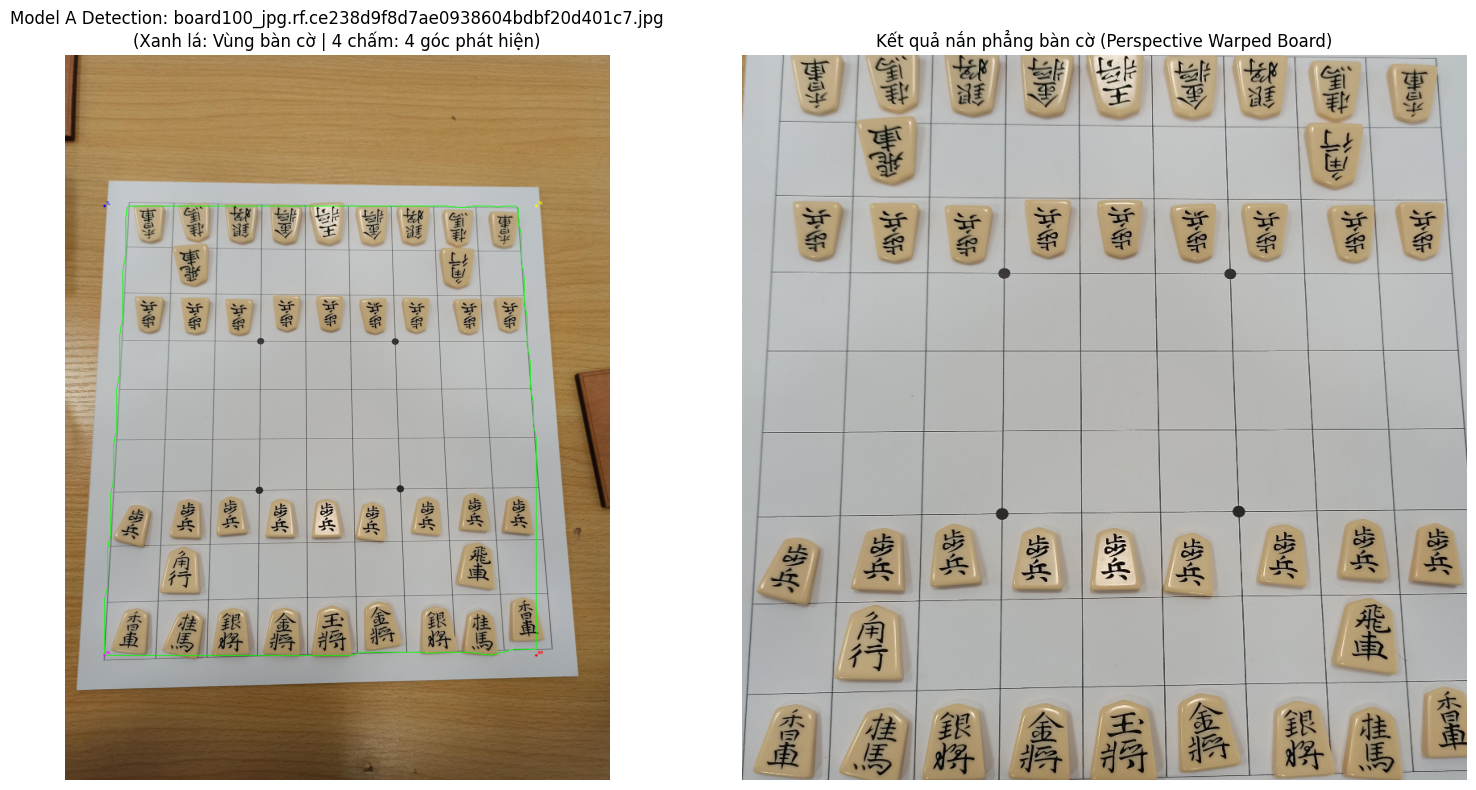

In [ ]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. XÁC ĐỊNH ĐƯỜNG DẪN MODEL A VÀ TẬP ẢNH TEST
# ============================================================
WORK_DIR = "/content"

# Tìm file trọng số Model A
if "model_a_path" not in globals() or not os.path.exists(model_a_path):
    candidates = glob.glob(f"{WORK_DIR}/runs/board_corner_seg*/weights/best.pt") + \
                 glob.glob(f"{WORK_DIR}/**/best.pt", recursive=True)
    if not candidates:
        raise FileNotFoundError("Không tìm thấy file trọng số best.pt của Model A!")
    model_a_path = max(candidates, key=os.path.getmtime)

print(f"Sử dụng trọng số: {model_a_path}")

# Tìm ảnh trong thư mục val hoặc train
test_image_dir = f"{WORK_DIR}/datasets/board_segmentation/board_segmentation/val/images"
if not os.path.exists(test_image_dir) or len(os.listdir(test_image_dir)) == 0:
    test_image_dir = f"{WORK_DIR}/datasets/board_segmentation/board_segmentation/train/images"

image_paths = glob.glob(f"{test_image_dir}/*.jpg") + glob.glob(f"{test_image_dir}/*.png")
if not image_paths:
    raise FileNotFoundError(f"Không tìm thấy ảnh nào trong: {test_image_dir}")

selected_img_path = random.choice(image_paths)
print(f"Ảnh được chọn test: {os.path.basename(selected_img_path)}")

# ============================================================
# 2. INFERENCE & TRÍCH XUẤT 4 GÓC BÀN CỜ
# ============================================================
out_dir = f"{WORK_DIR}/runs/test_model_a_predict"
base_name = os.path.splitext(os.path.basename(selected_img_path))[0]
txt_path = f"{out_dir}/labels/{base_name}.txt"

if os.path.exists(txt_path):
    os.remove(txt_path)

# Chạy YOLOv5 segmentation predict
cmd = f"python {WORK_DIR}/yolov5/segment/predict.py --weights {model_a_path} --source {selected_img_path} --img 960 --conf 0.4 --save-txt --project {WORK_DIR}/runs --name test_model_a_predict --exist-ok > /dev/null 2>&1"
os.system(cmd)

if not os.path.exists(txt_path):
    raise RuntimeError("Model A không phát hiện được bàn cờ trong ảnh này. Hãy thử ảnh khác hoặc giảm ngưỡng confidence.")

# Đọc tọa độ polygon từ file nhãn dự đoán
with open(txt_path, 'r') as f:
    lines = f.readlines()

coords = [float(x) for x in lines[0].strip().split()[1:]]
img_bgr = cv2.imread(selected_img_path)
h, w = img_bgr.shape[:2]

polygon = np.array([[coords[i] * w, coords[i + 1] * h] for i in range(0, len(coords), 2)], dtype=np.float32)

# Xác định khung chữ nhật xoay bọc quanh polygon và sắp xếp 4 góc
rect = cv2.minAreaRect(polygon)
box = cv2.boxPoints(rect)

def order_points(pts):
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    return np.array([pts[np.argmin(s)], pts[np.argmin(diff)], pts[np.argmax(s)], pts[np.argmax(diff)]], dtype=np.float32)

ordered_corners = order_points(box)

# ============================================================
# 3. PHỐI CẢNH (PERSPECTIVE WARP) BÀN CỜ
# ============================================================
out_size = 900
dst_pts = np.array([[0, 0], [out_size, 0], [out_size, out_size], [0, out_size]], dtype=np.float32)
M = cv2.getPerspectiveTransform(ordered_corners, dst_pts)
warped_bgr = cv2.warpPerspective(img_bgr, M, (out_size, out_size))

# ============================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ
# ============================================================
img_annotated = img_bgr.copy()

# Vẽ vùng phân vùng (polygon)
cv2.polylines(img_annotated, [np.int32(polygon)], isClosed=True, color=(0, 255, 0), thickness=3)

# Vẽ 4 góc phát hiện được
corner_colors = [(255, 0, 0), (0, 255, 255), (0, 0, 255), (255, 0, 255)] # Top-Left, Top-Right, Bottom-Right, Bottom-Left
corner_names = ["TL", "TR", "BR", "BL"]
for i, pt in enumerate(ordered_corners):
    x, y = int(pt[0]), int(pt[1])
    cv2.circle(img_annotated, (x, y), 8, corner_colors[i], -1)
    cv2.putText(img_annotated, corner_names[i], (x + 10, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, corner_colors[i], 2)

# Hiển thị biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

ax[0].imshow(cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB))
ax[0].set_title(f"Model A Detection: {os.path.basename(selected_img_path)}\n(Xanh lá: Vùng bàn cờ | 4 chấm: 4 góc phát hiện)")
ax[0].axis("off")

ax[1].imshow(cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2RGB))
ax[1].set_title("Kết quả nắn phẳng bàn cờ (Perspective Warped Board)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

# Train Model B (nhận biết quân cờ)

In [ ]:
import os
import glob
import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

WORK_DIR = "/content"
FIGURE_DATASET_DIR = f"{WORK_DIR}/datasets/figure_direction_classification"
if os.path.isdir(os.path.join(FIGURE_DATASET_DIR, "figure_direction_classification")):
    FIGURE_DATASET_DIR = os.path.join(FIGURE_DATASET_DIR, "figure_direction_classification")

FIGURE_CLASSES = sorted([d for d in os.listdir(FIGURE_DATASET_DIR) if os.path.isdir(os.path.join(FIGURE_DATASET_DIR, d))])
DIRECTION_CLASSES = ["UP", "DOWN"]

class PadToSquare:
    def __init__(self, fill=0):
        self.fill = fill
    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        if w == h: return img
        size = max(w, h)
        new_img = Image.new(img.mode, (size, size), color=self.fill)
        new_img.paste(img, ((size - w) // 2, (size - h) // 2))
        return new_img

class FigureDirectionDataset(Dataset):
    def __init__(self, root_dir):
        self.samples = []
        valid_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.PNG')
        for figure in FIGURE_CLASSES:
            figure_idx = FIGURE_CLASSES.index(figure)
            figure_path = os.path.join(root_dir, figure)
            if figure == "EMPTY":
                for ext in valid_extensions:
                    for img_path in glob.glob(f"{figure_path}/NONE/{ext}"):
                        self.samples.append((img_path, figure_idx, -1))
                continue
            for direction in DIRECTION_CLASSES:
                dir_idx = DIRECTION_CLASSES.index(direction)
                dir_path = os.path.join(figure_path, direction)
                if not os.path.isdir(dir_path): continue
                for ext in valid_extensions:
                    for img_path in glob.glob(f"{dir_path}/{ext}"):
                        self.samples.append((img_path, figure_idx, dir_idx))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, fig_idx, dir_idx = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return img, fig_idx, dir_idx

# Lớp bọc (Wrapper) để áp dụng Augmentation riêng cho Train và Val
class TransformDataset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, idx):
        img, fig, dir_idx = self.subset[idx]
        return self.transform(img), fig, dir_idx
    def __len__(self): return len(self.subset)

# TĂNG CƯỜNG DỮ LIỆU ĐỂ CHỐNG LẠI ẢNH ĐIỆN THOẠI BỊ NHIỄU, BÓNG MỜ
train_transform = transforms.Compose([
    PadToSquare(fill=0),
    transforms.Resize((224, 224)), # Nâng kích thước lên 128x128 để nét hơn
    transforms.RandomRotation(15), # Chống rung/nghiêng camera
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2), # Chống sai sáng
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Chuẩn ImageNet
])

val_transform = transforms.Compose([
    PadToSquare(fill=0),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

base_dataset = FigureDirectionDataset(FIGURE_DATASET_DIR)
train_size = int(0.85 * len(base_dataset))
val_size = len(base_dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(base_dataset, [train_size, val_size])

train_loader = DataLoader(TransformDataset(train_ds, train_transform), batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(TransformDataset(val_ds, val_transform), batch_size=64, num_workers=2)

print(f"Tổng số ảnh: {len(base_dataset)} | Train: {train_size} | Val: {val_size}")

Tổng số ảnh: 13929 | Train: 11839 | Val: 2090


In [ ]:
class MobileNetClassifier(nn.Module):
  def __init__(self, num_figures, num_directions=2, pretrained=False):
        super().__init__()
        # 1. Lấy backbone features từ MobileNetV2
        mobilenet = models.mobilenet_v2(weights=None)  # hoặc pretrained=False
        self.backbone = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # 2. Số chiều output của MobileNetV2 là 1280
        in_features = 1280

        # 3. Hai nhánh phân loại (Quân cờ & Hướng đi)
        self.fc_figure = nn.Linear(in_features, num_figures)
        self.fc_direction = nn.Linear(in_features, num_directions)

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.pool(feat)
        feat = torch.flatten(feat, 1)
        return self.fc_figure(feat), self.fc_direction(feat)

device = "cuda" if torch.cuda.is_available() else "cpu"
model_b = MobileNetClassifier(num_figures=len(FIGURE_CLASSES)).to(device)

print(f"Đã khởi tạo MobileNetV2. Huấn luyện trên: {device}")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 148MB/s]


Đã khởi tạo MobileNetV2. Huấn luyện trên: cuda


In [ ]:
EMPTY_IDX = FIGURE_CLASSES.index("EMPTY") if "EMPTY" in FIGURE_CLASSES else -1

criterion = nn.CrossEntropyLoss()
# AdamW tốt hơn Adam cho việc chống quá khớp
optimizer = optim.AdamW(model_b.parameters(), lr=1e-3, weight_decay=1e-4)
# Tự động giảm Learning Rate về cuối để model học mịn hơn
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40)

def run_epoch(loader, train=True):
    model_b.train(train)
    total_loss, correct_fig, correct_dir, n_dir = 0, 0, 0, 0
    for imgs, fig_labels, dir_labels in loader:
        imgs, fig_labels, dir_labels = imgs.to(device), fig_labels.to(device), dir_labels.to(device)

        if train: optimizer.zero_grad()

        pred_fig, pred_dir = model_b(imgs)
        loss_fig = criterion(pred_fig, fig_labels)

        mask = dir_labels != -1
        loss_dir = criterion(pred_dir[mask], dir_labels[mask]) if mask.sum() > 0 else torch.tensor(0.0, device=device)

        loss = loss_fig + loss_dir

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct_fig += (pred_fig.argmax(1) == fig_labels).sum().item()
        if mask.sum() > 0:
            correct_dir += (pred_dir[mask].argmax(1) == dir_labels[mask]).sum().item()
            n_dir += mask.sum().item()

    return total_loss / len(loader.dataset), correct_fig / len(loader.dataset), correct_dir / max(n_dir, 1)

In [ ]:
EPOCHS = 40
train_losses, val_losses, train_fig_accs, val_fig_accs = [], [], [], []

best_val_acc = 0.0
best_model_path = f"{WORK_DIR}/best_model_b_figure_direction.pt"

print("🚀 Bắt đầu huấn luyện MobileNetV2...")
for epoch in range(EPOCHS):
    tr_loss, tr_acc_f, tr_acc_d = run_epoch(train_loader, train=True)
    val_loss, val_acc_f, val_acc_d = run_epoch(val_loader, train=False)

    # Bước nhảy tốc độ học
    scheduler.step()

    train_losses.append(tr_loss); val_losses.append(val_loss)
    train_fig_accs.append(tr_acc_f); val_fig_accs.append(val_acc_f)

    # KỸ THUẬT QUAN TRỌNG: Chỉ lưu lại Model có Val Acc cao nhất
    if val_acc_f > best_val_acc:
        best_val_acc = val_acc_f
        torch.save(model_b.state_dict(), best_model_path)
        status = "🌟 ĐÃ LƯU BEST MODEL!"
    else:
        status = ""

    print(f"[{epoch+1:02d}/{EPOCHS}] Train Loss: {tr_loss:.3f} Acc: {tr_acc_f:.3f} | Val Loss: {val_loss:.3f} Val Acc: {val_acc_f:.3f} {status}")

print(f"\n✅ Hoàn tất! Model xuất sắc nhất đạt {best_val_acc*100:.2f}% độ chính xác.")

🚀 Bắt đầu huấn luyện MobileNetV2...
[01/40] Train Loss: 0.360 Acc: 0.915 | Val Loss: 0.064 Val Acc: 0.985 🌟 ĐÃ LƯU BEST MODEL!
[02/40] Train Loss: 0.053 Acc: 0.989 | Val Loss: 0.021 Val Acc: 0.999 🌟 ĐÃ LƯU BEST MODEL!
[03/40] Train Loss: 0.056 Acc: 0.989 | Val Loss: 0.010 Val Acc: 0.998 
[04/40] Train Loss: 0.028 Acc: 0.993 | Val Loss: 0.005 Val Acc: 0.999 
[05/40] Train Loss: 0.045 Acc: 0.993 | Val Loss: 0.035 Val Acc: 0.993 
[06/40] Train Loss: 0.018 Acc: 0.995 | Val Loss: 0.001 Val Acc: 1.000 🌟 ĐÃ LƯU BEST MODEL!
[07/40] Train Loss: 0.030 Acc: 0.996 | Val Loss: 0.050 Val Acc: 0.993 
[08/40] Train Loss: 0.032 Acc: 0.994 | Val Loss: 0.001 Val Acc: 1.000 🌟 ĐÃ LƯU BEST MODEL!
[09/40] Train Loss: 0.020 Acc: 0.996 | Val Loss: 0.002 Val Acc: 1.000 
[10/40] Train Loss: 0.008 Acc: 0.998 | Val Loss: 0.001 Val Acc: 1.000 
[11/40] Train Loss: 0.010 Acc: 0.998 | Val Loss: 0.001 Val Acc: 1.000 
[12/40] Train Loss: 0.005 Acc: 0.999 | Val Loss: 0.000 Val Acc: 1.000 
[13/40] Train Loss: 0.003 Acc: 0

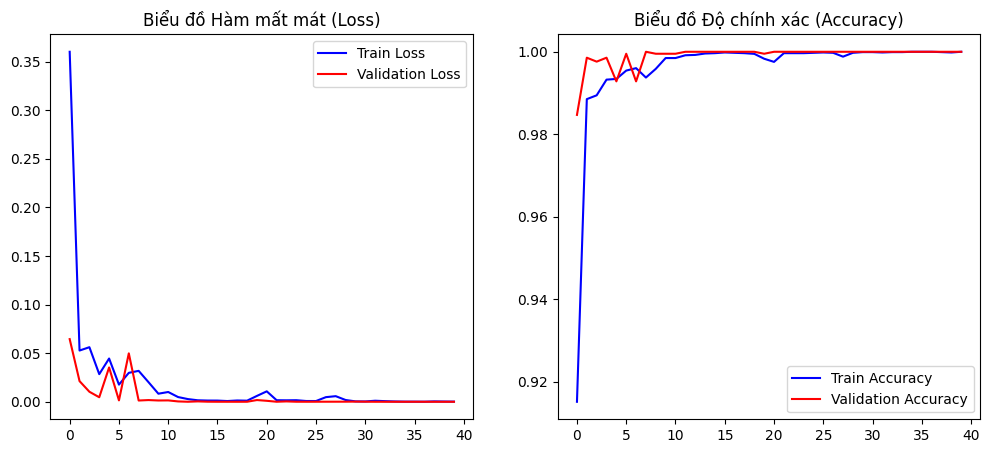

Đang tải /content/best_model_b_figure_direction.pt về máy...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from google.colab import files as colab_files

# Vẽ biểu đồ Accuracy và Loss để xem chống Overfitting có tốt không
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Validation Loss', color='red')
plt.title('Biểu đồ Hàm mất mát (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_fig_accs, label='Train Accuracy', color='blue')
plt.plot(val_fig_accs, label='Validation Accuracy', color='red')
plt.title('Biểu đồ Độ chính xác (Accuracy)')
plt.legend()
plt.show()

# Tải thẳng tệp Model xịn nhất về máy
print(f"Đang tải {best_model_path} về máy...")
colab_files.download(best_model_path)

# Test Model B (nhận biết quân cờ)

In [ ]:
# import glob, yaml

# # Kiem tra thuc te dataset board_segmentation dang co bao nhieu class
# _yaml_files = glob.glob(f"{WORK_DIR}/datasets/board_segmentation/**/*.yaml", recursive=True)
# if _yaml_files:
#     with open(_yaml_files[0]) as f:
#         _cfg = yaml.safe_load(f)
#     print("Noi dung data.yaml cua Model A (board_segmentation):")
#     print(f"  nc (so class)  : {_cfg.get('nc')}")
#     print(f"  names          : {_cfg.get('names')}")
#     print()
#     if _cfg.get('nc', 0) <= 1:
#         print("=> XAC NHAN: Model A chi phat hien 'ban co' (1 class), KHONG detect tung quan co.")
#         print("   Vi tri quan co duoc suy ra bang chia luoi hinh hoc sau khi warp, khong phai AI detect.")

In [ ]:
# import shutil, glob, os
# from IPython.display import display
# try:
#     from google.colab import files as colab_files
#     IN_COLAB = True
# except ImportError:
#     from IPython.display import FileLink
#     IN_COLAB = False

# def offer_download(path):
#     """Tai file ve may: dung google.colab.files tren Colab, FileLink khi chay noi khac."""
#     if IN_COLAB:
#         colab_files.download(path)
#     else:
#         display(FileLink(path))

# # Model A: tim thu muc run moi nhat mot cach DONG (khong hard-code ten)
# run_dirs = glob.glob(f"{WORK_DIR}/runs/board_corner_seg*")
# if run_dirs:
#     latest_run = max(run_dirs, key=os.path.getmtime)
#     zip_path = f"{WORK_DIR}/board_corner_seg_results"
#     shutil.make_archive(zip_path, 'zip', latest_run)
#     print(f"Model A (best.pt + results) tai: {latest_run}/weights/best.pt")
#     %cd {WORK_DIR}
#     offer_download("board_corner_seg_results.zip")
# else:
#     print("Khong tim thay ket qua train Model A.")

# # Model B
# model_b_path = f"{WORK_DIR}/model_b_figure_direction.pt"
# if os.path.exists(model_b_path):
#     print(f"\nModel B tai: {model_b_path}")
#     offer_download("model_b_figure_direction.pt")
# else:
#     print("Khong tim thay model_b_figure_direction.pt")


FileNotFoundError: Khong tim thay best.pt. Hay upload file (cell Upload model) hoac train Model A.

In [ ]:
import cv2
import numpy as np
import os

# ============================================================
# 3. DINH NGHIA PIPELINE (mot lan duy nhat, khong lap lai)
# ============================================================
def order_corners(pts):
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1).flatten()
    return np.array([pts[np.argmin(s)], pts[np.argmin(diff)], pts[np.argmax(s)], pts[np.argmax(diff)]], dtype=np.float32)

def expand_corners(corners, scale_x=1.05, scale_y=1.08):
    """Phóng to khung cắt ra ngoài tâm. Trục Y (chiều dọc) phóng to nhiều hơn (1.08)
       để bù đắp cho phần đầu quân cờ nhô lên cao."""
    center = np.mean(corners, axis=0)
    expanded = []
    for pt in corners:
        dx = (pt[0] - center[0]) * scale_x
        dy = (pt[1] - center[1]) * scale_y
        expanded.append([center[0] + dx, center[1] + dy])
    return np.array(expanded, dtype=np.float32)

def detect_board_corners(model_weights_path, image_path):
    out_dir = "/content/runs/temp_predict"
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    txt_path = f"{out_dir}/labels/{base_name}.txt"
    if os.path.exists(txt_path): os.remove(txt_path)

    cmd = f"python /content/yolov5/segment/predict.py --weights {model_weights_path} --source {image_path} --img 960 --conf 0.5 --save-txt --project /content/runs --name temp_predict --exist-ok > /dev/null 2>&1"
    os.system(cmd)

    with open(txt_path, 'r') as f: lines = f.readlines()
    coords = [float(x) for x in lines[0].strip().split()[1:]]
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    polygon = [[coords[i] * w, coords[i+1] * h] for i in range(0, len(coords), 2)]
    rect = cv2.minAreaRect(np.array(polygon, dtype=np.float32))
    return order_corners(cv2.boxPoints(rect))

def warp_board(image, corners, out_size=900):
    dst = np.array([[0, 0], [out_size, 0], [out_size, out_size], [0, out_size]], dtype=np.float32)
    H = cv2.getPerspectiveTransform(corners, dst)
    return cv2.warpPerspective(image, H, (out_size, out_size))

# def split_into_cells(warped_board, n=9):
#     h, w = warped_board.shape[:2]
#     cell_h, cell_w = h // n, w // n
#     return {
#         (r, c): warped_board[r*cell_h:(r+1)*cell_h, c*cell_w:(c+1)*cell_w]
#         for r in range(n) for c in range(n)
#     }

def predict_cell(model_b, cell_img_bgr, transform, device):
    img_rgb = cv2.cvtColor(cell_img_bgr, cv2.COLOR_BGR2RGB)
    tensor = transform(Image.fromarray(img_rgb)).unsqueeze(0).to(device)
    model_b.eval()
    with torch.no_grad():
        pred_fig, pred_dir = model_b(tensor)
        fig_idx, dir_idx = pred_fig.argmax(1).item(), pred_dir.argmax(1).item()
    figure = FIGURE_CLASSES[fig_idx]
    direction = DIRECTION_CLASSES[dir_idx] if figure != "EMPTY" else None
    return figure, direction

def split_into_cells_with_margin(warped_paper, margins, pad_sides=6, n=9):
    mt, mb, ml, mr = margins
    h, w = warped_paper.shape[:2]
    grid_w = w - ml - mr
    grid_h = h - mt - mb
    cell_w = grid_w / n
    cell_h = grid_h / n

    cells = {}
    for row in range(n):
        for col in range(n):
            x1 = ml + col * cell_w
            y1 = mt + row * cell_h
            x2 = ml + (col + 1) * cell_w
            y2 = mt + (row + 1) * cell_h

            # Padding theo hàng – đã giảm pad_bottom nửa trên
            if row <= 3:          # nửa trên
                pad_top, pad_bottom = 8, 6    # giảm pad_bottom xuống 6
            else:                 # nửa dưới
                pad_top, pad_bottom = 22, 6

            crop_x1 = max(0, int(x1 - pad_sides))
            crop_x2 = min(w, int(x2 + pad_sides))
            crop_y1 = max(0, int(y1 - pad_top))
            crop_y2 = min(h, int(y2 + pad_bottom))

            cells[(row, col)] = warped_paper[crop_y1:crop_y2, crop_x1:crop_x2]
    return cells

def analyze_board_image(image_path, model_weights_path, model_b, transform, device):
    image = cv2.imread(image_path)
    corners = detect_board_corners(model_weights_path, image_path)

    # Phóng to khung để lấy trọn đầu quân (nếu bạn đã thêm)
    corners = expand_corners(corners, scale_x=1.06, scale_y=1.12)

    warped_paper = warp_board(image, corners, out_size=900)

    # Có thể tăng margins nếu cần
    margins = (35, 35, 35, 35)   # top, bottom, left, right

    # Gọi hàm cắt (không còn pad_top / pad_bottom)
    cells = split_into_cells_with_margin(warped_paper, margins, pad_sides=10)

    board_state = {}
    fig, axes = plt.subplots(2, 9, figsize=(18, 4))
    for col in range(9):
        axes[0, col].imshow(cv2.cvtColor(cells[(0, col)], cv2.COLOR_BGR2RGB))
        axes[0, col].set_title(f"R0 C{col}")
        axes[0, col].axis("off")

        axes[1, col].imshow(cv2.cvtColor(cells[(8, col)], cv2.COLOR_BGR2RGB))
        axes[1, col].set_title(f"R8 C{col}")
        axes[1, col].axis("off")
    plt.tight_layout()
    plt.show()

    for (row, col), cell_img in cells.items():
        figure, direction = predict_cell(model_b, cell_img, transform, device)
        board_state[(row, col)] = (figure, direction)

    return board_state, warped_paper

def print_board_state(board_state, n=9):
    for row in range(n):
        line = []
        for col in range(n):
            figure, direction = board_state[(row, col)]
            if figure == "EMPTY":
                line.append(" .  ")
            else:
                mark = "^" if direction == "UP" else "v"
                line.append(f"{figure[:2]}{mark}")
        print(" ".join(f"{c:>5}" for c in line))

print("Da dinh nghia xong pipeline test.")

Da dinh nghia xong pipeline test.


In [ ]:
import os, glob, random
from PIL import Image
import torch

# Đường dẫn gốc dataset Model B (đã nested 2 lần)
FIGURE_ROOT = "/content/datasets/figure_direction_classification/figure_direction_classification"

# Lấy ngẫu nhiên 1 ảnh từ bất kỳ thư mục quân cờ nào (trừ EMPTY nếu muốn)
all_images = []
for fig in os.listdir(FIGURE_ROOT):
    fig_path = os.path.join(FIGURE_ROOT, fig)
    if not os.path.isdir(fig_path):
        continue
    # Quét cả UP / DOWN / NONE
    for dirpath, _, filenames in os.walk(fig_path):
        for f in filenames:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                all_images.append(os.path.join(dirpath, f))

print(f"Tìm thấy {len(all_images)} ảnh trong dataset")

# Chọn ngẫu nhiên 100 ảnh để test
samples = random.sample(all_images, min(100, len(all_images)))

model_b.eval()
for path in samples:
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_fig, pred_dir = model_b(tensor)
        fig_idx = pred_fig.argmax(1).item()
        dir_idx = pred_dir.argmax(1).item()

    true_fig = path.split(os.sep)[-3] if "EMPTY" not in path else "EMPTY"
    true_dir = path.split(os.sep)[-2]

    pred_fig_name = FIGURE_CLASSES[fig_idx]
    pred_dir_name = DIRECTION_CLASSES[dir_idx] if pred_fig_name != "EMPTY" else "NONE"

    print(f"Ảnh: {os.path.basename(path)}")
    print(f"  Thật  → {true_fig:12} | {true_dir}")
    print(f"  Đoán → {pred_fig_name:12} | {pred_dir_name}")
    print("-" * 40)

Tìm thấy 13931 ảnh trong dataset
Ảnh: 956.jpg
  Thật  → PAWN         | DOWN
  Đoán → PAWN         | DOWN
----------------------------------------
Ảnh: 103.jpg
  Thật  → LANCE        | UP
  Đoán → LANCE        | UP
----------------------------------------
Ảnh: 3375.jpg
  Thật  → EMPTY        | NONE
  Đoán → EMPTY        | NONE
----------------------------------------
Ảnh: 771.jpg
  Thật  → PAWN         | DOWN
  Đoán → PAWN         | DOWN
----------------------------------------
Ảnh: 5565.jpg
  Thật  → EMPTY        | NONE
  Đoán → EMPTY        | NONE
----------------------------------------
Ảnh: 177.jpg
  Thật  → GOLD         | UP
  Đoán → GOLD         | UP
----------------------------------------
Ảnh: 486.jpg
  Thật  → PAWN         | DOWN
  Đoán → PAWN         | DOWN
----------------------------------------
Ảnh: 77.jpg
  Thật  → SILVER       | DOWN
  Đoán → SILVER       | DOWN
----------------------------------------
Ảnh: 2687.jpg
  Thật  → EMPTY        | NONE
  Đoán → EMPTY        | NO

# Test Model A + B

In [ ]:
test_image_path = random.choice(test_images)
print(f"Đang phân tích ảnh: {os.path.basename(test_image_path)}")

try:
    # Nhận đủ 2 biến từ hàm trả về
    board_state, warped = analyze_board_image(test_image_path, model_a_path, model_b, transform, device)

    print("\n" + "="*40)
    print("KẾT QUẢ ĐỌC BÀN CỜ (AI DỰ ĐOÁN)")
    print("="*40)
    print_board_state(board_state)
    print("="*40)

    # Chuyển hệ màu để Matplotlib hiển thị đúng (không bị thành màu xanh lè)
    image_rgb = cv2.cvtColor(cv2.imread(test_image_path), cv2.COLOR_BGR2RGB)
    warped_rgb = cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 7))

    plt.subplot(1, 2, 1)
    plt.imshow(image_rgb)
    plt.title("Ảnh chụp ban đầu")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(warped_rgb)
    plt.title("Đã nắn phẳng và Cắt lề chuẩn 9x9")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

except Exception:
    print("Có lỗi xảy ra trong quá trình nhận diện:")
    traceback.print_exc()

In [ ]:
# # ============================================================
# # 5. (TUY CHON) TEST TREN NHIEU ANH DE KIEM TRA DO ON DINH
# # ============================================================
# N_SAMPLES = min(5, len(test_images))
# sample_images = random.sample(test_images, N_SAMPLES)

# for img_path in sample_images:
#     print(f"\n>>> {os.path.basename(img_path)}")
#     try:
#         board_state, _ = analyze_board_image(img_path, model_a_path, model_b, transform, device)
#         n_pieces = sum(1 for v in board_state.values() if v[0] != "EMPTY")
#         print(f"Số ô được nhận diện: {n_pieces} / 81")
#     except Exception as e:
#         print(f"Lỗi: {e}")

# Vẽ đồ thị

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob
import os

WORK_DIR = "/content"
# Tự động tìm thư mục huấn luyện mới nhất của YOLOv5
run_dirs = glob.glob(f"{WORK_DIR}/runs/board_corner_seg*")

if not run_dirs:
    print("Không tìm thấy thư mục kết quả của YOLOv5.")
else:
    latest_run = max(run_dirs, key=os.path.getmtime)
    results_img_path = f"{latest_run}/results.png"

    if os.path.exists(results_img_path):
        print(f"Đang hiển thị biểu đồ của Model A tại: {latest_run}")
        img = cv2.imread(results_img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(18, 10))
        plt.imshow(img)
        plt.axis('off')
        plt.title("Biểu đồ Huấn luyện của Model A (YOLOv5 Segmentation)", fontsize=16, pad=20)
        plt.show()
    else:
        print(f"Không tìm thấy file results.png trong {latest_run}")

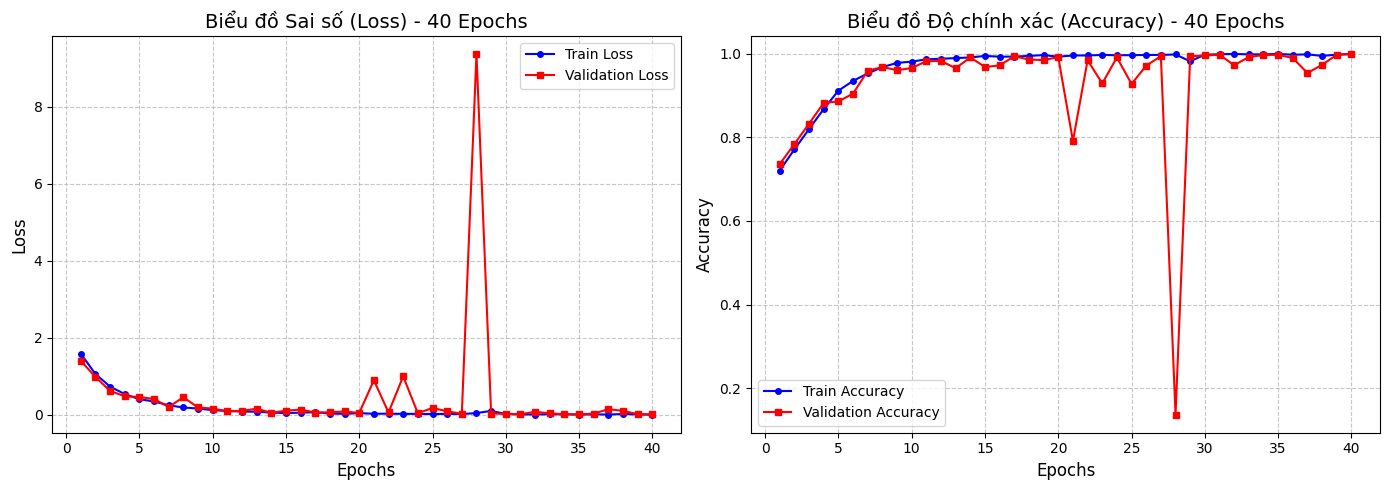

In [ ]:
# ====================================================
# VẼ BIỂU ĐỒ MODEL B SAU KHI TRAIN XONG (CHỈ LẤY EPOCHS CUỐI)
# ====================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Cắt mảng để chỉ lấy đúng số lượng kết quả của lần train gần nhất
current_train_losses = train_losses[-EPOCHS:]
current_val_losses = val_losses[-EPOCHS:]
current_train_accs = train_fig_accs[-EPOCHS:]
current_val_accs = val_fig_accs[-EPOCHS:]

epochs_range = range(1, EPOCHS + 1)

# Biểu đồ Loss Curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, current_train_losses, label='Train Loss', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, current_val_losses, label='Validation Loss', color='red', marker='s', markersize=4)
plt.title(f'Biểu đồ Sai số (Loss) - {EPOCHS} Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Biểu đồ Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, current_train_accs, label='Train Accuracy', color='blue', marker='o', markersize=4)
plt.plot(epochs_range, current_val_accs, label='Validation Accuracy', color='red', marker='s', markersize=4)
plt.title(f'Biểu đồ Độ chính xác (Accuracy) - {EPOCHS} Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Khác

In [ ]:
!pip install -q fastapi uvicorn python-multipart nest-asyncio pyngrok

from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
import nest_asyncio, uvicorn
from pyngrok import ngrok
import cv2, numpy as np
from PIL import Image
import io

app = FastAPI(title="Shogi / Object Detection API")

@app.get("/")
def health():
    return {"status": "ok"}

@app.post("/detect")
async def detect(file: UploadFile = File(...)):
    contents = await file.read()
    # decode ảnh → chạy model A + B (hoặc YOLO thuần)
    # trả JSON: boxes, classes, confidences
    return JSONResponse({"detections": [...]})

# Chạy trong Colab
nest_asyncio.apply()
public_url = ngrok.connect(8000).public_url
print("API:", public_url)
uvicorn.run(app, host="0.0.0.0", port=8000)

In [ ]:
!pip install -q fastapi uvicorn python-multipart nest-asyncio pyngrok

from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
import nest_asyncio, uvicorn
from pyngrok import ngrok
import cv2, numpy as np
from PIL import Image
import io

app = FastAPI(title="Shogi / Object Detection API")

@app.get("/")
def health():
    return {"status": "ok"}

@app.post("/detect")
async def detect(file: UploadFile = File(...)):
    contents = await file.read()
    # decode ảnh → chạy model A + B (hoặc YOLO thuần)
    # trả JSON: boxes, classes, confidences
    return JSONResponse({"detections": [...]})

# Chạy trong Colab
nest_asyncio.apply()
public_url = ngrok.connect(8000).public_url
print("API:", public_url)
uvicorn.run(app, host="0.0.0.0", port=8000)